In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import networkx as nx
from collections import defaultdict
from itertools import combinations
from Bio.Align import PairwiseAligner, substitution_matrices

# Cross-reactivity clustering for PhIP-Seq hit peptides. 

## Pipeline: 
1. seed candidate pairs with reduced-alphabet k-mers (conservative substitution still matches)
2. score each candidate pair with BLOSUM62 Smith-Waterman. 
3. threshold + union-find into clusters

In [5]:
meta = pd.read_csv('lassa_library_sequences_species_standardized_070726_ICTV_corrected.csv')
df = pd.read_csv('long_091826.csv')
hits = pd.read_csv('pep_hits_wo_taxa_to_remove_091826.csv').set_index('peptide')

In [6]:
hits = hits.drop(columns='Unnamed: 0')

In [26]:
sequences = hits['sequence'].to_dict() #this keeps the peptide index

### Murphyn et al., (2000) 10-letter reduction. K/R, D/E/N/Q, F/Y/W etc. collapse. 
### rationale here is to reduce the alphabet prior to k-mer clustering. an exact k-mer would miss amino acids which as physiochemically very similar and don't influence antibody binding. 

In [7]:
MURPHY10 = {
    **dict.fromkeys("LVIM", "L"),
    **dict.fromkeys("C", "C"), 
    **dict.fromkeys("A", "A"), 
    **dict.fromkeys("G", "G"), 
    **dict.fromkeys("ST", "S"), 
    **dict.fromkeys("P", "P"), 
    **dict.fromkeys('FYW', "F"), 
    **dict.fromkeys("EDNQ", "E"), 
    **dict.fromkeys("KR", "K"), 
    **dict.fromkeys("H", "H")

}

In [8]:
def reduce_alphabet(seq):
    return "".join(MURPHY10.get(aa, "X") for aa in str(seq).upper())

### find shared 6-mers -> reduced alphabet is less specific per position

In [9]:
K = 6

def get_kmers(sequence, k = K):
    sequence = str(sequence).upper()
    return {
        sequence[i: i+k] for i in range(len(sequence)-k + 1)
    }

kmer_to_peps = defaultdict(list)

for idx, seq in hits['sequence'].items():

    for kmer in get_kmers(seq):
        kmer_to_peps[kmer].append(idx) #dict key = value

In [ ]:
def candidate_pairs(k=K, sequences):
    """
    sequences: dict {peptide_id -> sequence}. returns a set of (id_a, id_b)
    """
    kmer_to_peps = defaultdict(list)

    for idx, seq in sequences.items():
        for kmer in get_kmers(reduce_alphabet(seq), k):
            kmer_to_peps[kmer].append(idx)

    pairs = set()
    for kmer, idxs in kmer_to_peps.items():
        if len(idxs) < 2:
            continue
        for a, b in combinations(sorted(idxs), 2): #makes every peptide pair for that k-mer, so all possible pairs of peptide indices sharing that kmer, sorted() ensures pair always represented as smaller_index, larger_index
            pairs.add((a, b)) #set() removes redundance, important as two peptides may share multiple kmers. 
            #essentially, set contains unique pairs of peptide indices that share at least one k-mer. candidate edges!
    return pairs


### alignment

In [ ]:
BLOSUM62 = substitution_matrices.load("BLOSUM62")

def make_aligner():
    aln = PairwiseAligner()
    aln.mode = 'local' #Smith-Waterman
    aln.substitution_matrix = BLOSUM62
    aln.open_gap_score = -10 # BLAST protein defaults are -11 and -1, but I used -10 and -0.5 for the peptide to protein alignment. 
    aln.extend_gap_score = -0.5
    return aln

def self_score(aligner, seq):
    return aligner.score(seq, seq)

def normalized_similarity(aligner, seq_a, seq_b, self_a, self_b):
    """
    raw SW scores are not comparable across peptide pairs of different length or composition. 
    Dividing by the smaller self-alignment score, so 1.0 means that the shorter peptide is fully contained with no mismatches
    """
    raw = aligner.score(seq_a, seq_b)
    denom = min(self_a, self_b)
    return raw / denom if denom > 0 else 0.0


def score_pairs(sequences, pairs, threshold=0.5):
    """
    Returns [(id_a, id_b, similarity]) for pairs above a threshold"""
    aligner = make_aligner()
    selfs = {pid: self_score(aligner, seq) for pid, seq in hits['sequences'].items()}

    edges = []
    for a, b in pairs:
        sim = normalized_similarity(
            aligner, sequences[a], sequences[b], selfs[a], selfs[b]
        )
        if sim >= threshold:
            edges.append((a, b, sim))
    return edges



## define the similarity matrix 

In [ ]:
def similarity_matrix(sequences, progress_every=200):
    """
    Full all-vs-all normalized similarity.
    
    Returns (idx, matrix), where matrix is a square list-of-list of floats
    """
    idx = list(sequences)
    aligner = make_aligner()
    seqs = [sequences[i] for i in idx]
    selfs = [aligner.score(s, s) for s in seqs]

    n = len(idx)
    mat = [[0.0] * n for _ in range(n)]
    for i in range(n):
        mat[i][i] = 1.0
        for j in range(i + 1, n):
            denom = min(selfs[i], selfs[j])
            sim = aligner.score(seqs[i], seqs[j]) / denom if denom > 0 else 0.0
            mat[i][j] = mat[j][i] = sim
        if progress_every and (i + 1) % progress_every == 0:
            print(f"  aligned {i + 1}/{n} rows")
    return idx, mat

def matrix_to_edges(idx, mat, threshold=0.5):
    return[
        (idx[i], idx[j], mat[i][j]) for i in range(len(idx))for j in range(i + 1, len(idx)) if mat[i][j] >= threshold
    ]

## clustering

In [ ]:
class UnionFind:
    def __init__(self, items):
        self.parent = {i: i for i in items}

    def find(self, x):
        while self.parent[x] != x:
            self.parent[x] = self.parent[self.parent[x]]
            x = self.parent[x]
        return x

    def union(self, a, b):
        ra, rb = self.find(a), self.find(b)
        if ra != rb:
            self.parent[rb] = ra

## filter to kmers that occur in more than only one peptide!

In [22]:
shared_kmers = {
    #items() returns key value pairs in dictionary as tuples
    kmer: peptides for kmer, peptides in kmer_to_peps.items() if len(peptides) > 1
}

list(shared_kmers.items())[:10]

[('FNTSSI',
  ['AAA16239.1|polypeptide|Orthohantavirus_thailandense|isolate=?|?|?|?|segment=?|strain=Thai749|tile_41',
   'BCH41978.1|glycoprotein|Anjozorobe_virus|isolate=?|Rattus_rattus|Sri_Lanka|2019|segment=M|strain=Anjozorobe/2019/PR108|tile_40',
   'QBH69876.1|precursor|Orthohantavirus_dobravaense|isolate=DOB-SOCHI|Homo_sapiens|?|?|segment=M|strain=?|tile_41']),
 ('DHINIV',
  ['AAA16239.1|polypeptide|Orthohantavirus_thailandense|isolate=?|?|?|?|segment=?|strain=Thai749|tile_41',
   'XPA18833.1|glycoprotein|Orthohantavirus_seoulense|isolate=?|?|Russia:_Primorsky_Krai|02-Mar-2015|segment=M|strain=SEOV/Russia_Vladivostok/R-6357-15/2015|tile_41']),
 ('TKDIDF',
  ['AAA16239.1|polypeptide|Orthohantavirus_thailandense|isolate=?|?|?|?|segment=?|strain=Thai749|tile_41',
   'QBH69876.1|precursor|Orthohantavirus_dobravaense|isolate=DOB-SOCHI|Homo_sapiens|?|?|segment=M|strain=?|tile_41']),
 ('SFQSFN',
  ['AAA16239.1|polypeptide|Orthohantavirus_thailandense|isolate=?|?|?|?|segment=?|strain=Th

In [19]:
print('Number of shared 7-mers', len(shared_kmers))

Number of shared 7-mers 3800


## assign the shared 7-mers to cluster

In [20]:
shared_kmers.items() #to tuple

dict_items([('IHFTDER', ['AAA16239.1|polypeptide|Orthohantavirus_thailandense|isolate=?|?|?|?|segment=?|strain=Thai749|tile_41', 'BCH41978.1|glycoprotein|Anjozorobe_virus|isolate=?|Rattus_rattus|Sri_Lanka|2019|segment=M|strain=Anjozorobe/2019/PR108|tile_40', 'XPA18833.1|glycoprotein|Orthohantavirus_seoulense|isolate=?|?|Russia:_Primorsky_Krai|02-Mar-2015|segment=M|strain=SEOV/Russia_Vladivostok/R-6357-15/2015|tile_41']), ('TSSIHFT', ['AAA16239.1|polypeptide|Orthohantavirus_thailandense|isolate=?|?|?|?|segment=?|strain=Thai749|tile_41', 'BCH41978.1|glycoprotein|Anjozorobe_virus|isolate=?|Rattus_rattus|Sri_Lanka|2019|segment=M|strain=Anjozorobe/2019/PR108|tile_40']), ('SIHFTDE', ['AAA16239.1|polypeptide|Orthohantavirus_thailandense|isolate=?|?|?|?|segment=?|strain=Thai749|tile_41', 'BCH41978.1|glycoprotein|Anjozorobe_virus|isolate=?|Rattus_rattus|Sri_Lanka|2019|segment=M|strain=Anjozorobe/2019/PR108|tile_40']), ('VTKDIDF', ['AAA16239.1|polypeptide|Orthohantavirus_thailandense|isolate=?|?

In [28]:
G = nx.Graph()

#adding every peptide as a node
G.add_nodes_from(hits.index)

for kmer, idxs in shared_kmers.items():
    if len(idxs) > 1:
        first = idxs[0]

        for idx in idxs[1:]:
            G.add_edge(first, idx)

In [ ]:
#nx.connected_components function to find all the self-contained groups of nodes (connected components)
#in a graph
components = list(nx.connected_components(G))

print('number of clusters', len(components))

number of clusters 813


In [ ]:
#extract the size (number of nodes) of each connected component
cluster_size = [len(c) for c in components]

pd.Series(cluster_size).value_counts().sort_index()

1     643
2      95
3      33
4       8
5       3
6       7
7       4
8       4
9       4
10      2
12      3
13      1
14      2
15      1
17      2
24      1
Name: count, dtype: int64

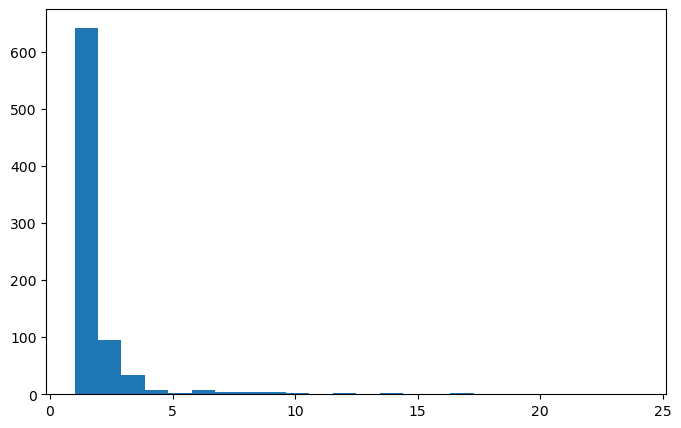

In [35]:
plt.figure(figsize=(8,5))
plt.hist(cluster_size, bins=max(cluster_size))
plt.show()